In [1]:
%env JAX_PLATFORM_NAME=cpu

from test.helpers import get_bqp, get_harmonic_oscillator

import jax.numpy as jnp
import jax.random as jrandom
import matplotlib.pyplot as plt
from diffrax import diffeqsolve, SaveAt
from diffrax.solver.foster_srk import FosterSRK
from jax import config


config.update("jax_enable_x64", True)
jnp.set_printoptions(precision=4, suppress=True)


# Plotting
def draw_order(hs, errs):
    plt.plot(1 / hs, errs)
    plt.yscale("log")
    plt.xscale("log")
    pretty_hs = ["{0:0.4f}".format(h) for h in hs]
    plt.xticks(ticks=1 / hs, labels=pretty_hs)
    plt.ylabel("RMS error")
    plt.xlabel("step size")
    plt.show()
    slope, _ = jnp.polyfit(jnp.log(hs), jnp.log(errs), 1)
    print(f"Order of convergence: {slope:.4f}")


def plot_sol(sol):
    plt.plot(sol.ts, sol.ys[0], label="x")
    plt.plot(sol.ts, sol.ys[1], label="v")
    plt.legend()
    plt.show()


dtype = jnp.float64
key = jrandom.PRNGKey(2)
num_samples = 100
keys = jrandom.split(jrandom.PRNGKey(5678), num=num_samples)
hs1 = jnp.power(2.0, jnp.arange(-3, -8, -1, dtype=dtype))


def get_dtype(x):
    if type(x) in [int, float, str]:
        return type(x)
    else:
        return jnp.dtype(x)


t0, t1 = 0.3, 15
saveat = SaveAt(ts=jnp.linspace(t0, t1, 1000))
dt0 = 0.1

t0_typed, t1_typed = dtype(0.3), dtype(15)
saveat_typed = SaveAt(ts=jnp.linspace(t0, t1, 1000, dtype=dtype))
dt0_typed = dtype(0.1)

hosc = get_harmonic_oscillator(0.3, 15.0, dtype=dtype)
terms_hosc = hosc.get_terms(hosc.get_bm(key, levy_area="space-time", tol=2**-10))
hosc_short = get_harmonic_oscillator(0.3, 5.1, dtype=dtype)

bqp = get_bqp(0.3, 15.0, dtype=dtype)
terms_bqp = bqp.get_terms(bqp.get_bm(key, levy_area="space-time", tol=2**-10))
bqp_short = get_bqp(0.3, 5.1, dtype=dtype)

env: JAX_PLATFORM_NAME=cpu


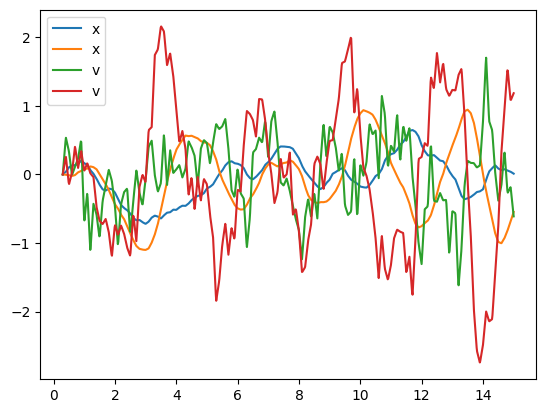

In [2]:
solFosSRK = diffeqsolve(
    terms_hosc, FosterSRK(), t0, t1, dt0=dt0, y0=hosc.y0, args=hosc.args, saveat=saveat
)
plot_sol(solFosSRK)

In [10]:
from test.helpers import SDE, sde_solver_order

import equinox as eqx
from diffrax import ControlTerm, MultiTerm, ODETerm


def _squareplus(x):
    return 0.5 * (x + jnp.sqrt(x**2 + 4))


def drift(t, y, args):
    mlp, _, _ = args
    return 0.5 * mlp(y)


def diffusion(t, y, args):
    _, mlp, noise_dim = args
    return 0.25 * mlp(y).reshape(3, noise_dim)


def sde_strong_order(solver_ctr, commutative=False):
    key = jrandom.PRNGKey(5678)
    driftkey, diffusionkey, ykey, bmkey = jrandom.split(key, 4)
    num_samples = 10
    bmkeys = jrandom.split(bmkey, num=num_samples)

    if commutative:
        noise_dim = 1
    else:
        noise_dim = 5

    drift_mlp = eqx.nn.MLP(
        in_size=3,
        out_size=3,
        width_size=8,
        depth=1,
        activation=_squareplus,
        key=driftkey,
    )
    diffusion_mlp = eqx.nn.MLP(
        in_size=3,
        out_size=3 * noise_dim,
        width_size=8,
        depth=1,
        activation=_squareplus,
        final_activation=jnp.tanh,
        key=diffusionkey,
    )
    args = (drift_mlp, diffusion_mlp, noise_dim)

    t0 = 0
    t1 = 2
    y0 = jrandom.normal(ykey, (3,), dtype=jnp.float64)

    def get_terms(bm):
        return MultiTerm(ODETerm(drift), ControlTerm(diffusion, bm))

    sde = SDE(get_terms, args, y0, t0, t1, (noise_dim,))

    # Reference solver is always an ODE-viable solver, so its implementation has been
    # verified by the ODE tests like test_ode_order.
    hs = jnp.power(2.0, jnp.arange(-4, -10, -1, dtype=dtype))
    hs, errors, order = sde_solver_order(
        bmkeys, sde, solver_ctr(), solver_ctr(), 2**-12, hs=hs
    )
    draw_order(hs, errors)
    return hs, errors, order

In [4]:
driftkey, diffusionkey, ykey, bmkey = jrandom.split(key, 4)
noise_dim = 3
drift_mlp = eqx.nn.MLP(
    in_size=3,
    out_size=3,
    width_size=8,
    depth=1,
    activation=_squareplus,
    key=driftkey,
)
diffusion_mlp = eqx.nn.MLP(
    in_size=3,
    out_size=3 * noise_dim,
    width_size=8,
    depth=1,
    activation=_squareplus,
    final_activation=jnp.tanh,
    key=diffusionkey,
)
args = (drift_mlp, diffusion_mlp, noise_dim)

t0 = 0.0
t1 = 2.0
y0 = jrandom.normal(ykey, (3,), dtype=jnp.float64)


def get_terms(bm):
    return MultiTerm(ODETerm(drift), ControlTerm(diffusion, bm))


sde = SDE(get_terms, args, y0, t0, t1, (noise_dim,))

bm = sde.get_bm(key, levy_area="space-time", tol=2**-10)
terms = sde.get_terms(bm)

solver = FosterSRK()
init = solver.init(terms, t0, t1, y0, args)

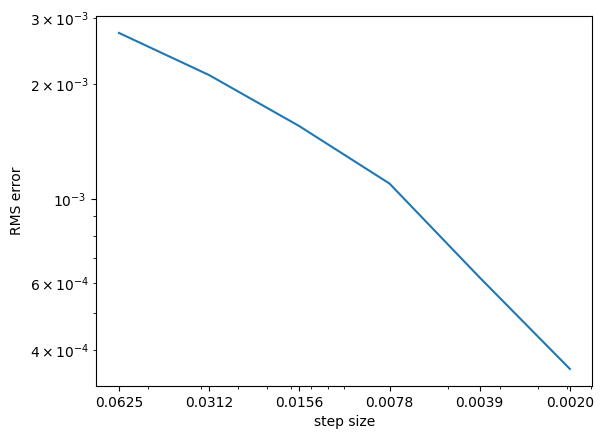

Order of convergence: 0.5858


In [11]:
out = sde_strong_order(FosterSRK, commutative=False)

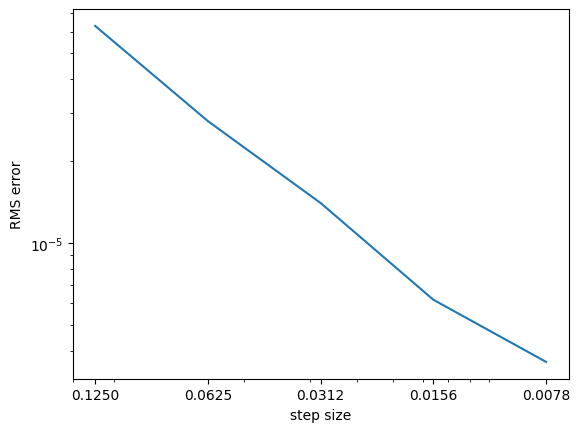

Order of convergence: 1.0409


In [6]:
out_commutative = sde_strong_order(FosterSRK, commutative=True)

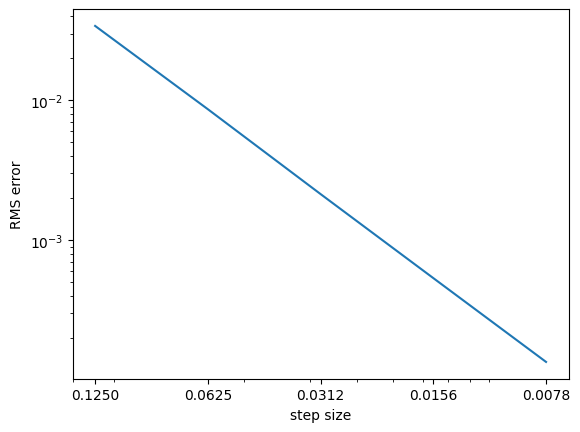

Order of convergence: 1.9994


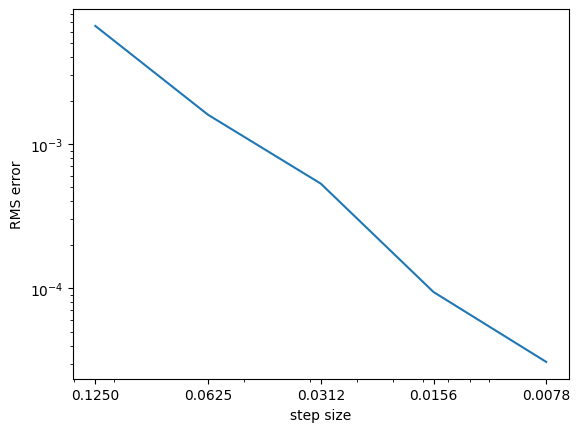

Order of convergence: 1.9577


In [7]:
from diffrax import ALIGN


hs, FosSRK_errs_hosc, _ = sde_solver_order(
    keys, hosc, FosterSRK(), ALIGN(0.1), 2**-12, hs=hs1
)
draw_order(hs, FosSRK_errs_hosc)
hs, FosSRK_errs_bqp, _ = sde_solver_order(
    keys, bqp, FosterSRK(), ALIGN(0.1), 2**-12, hs=hs1
)
draw_order(hs, FosSRK_errs_bqp)